# Experimental Evaluation Using MLP
## Authors
*   Gabriel de Oliveira Pontarolo
*   Jennifer Mayara de Paiva Goberski
   
## References
* Adapted from original notebook from Vítor Gama Lemos [*Multi-layer Perceptron from Scratch*](https://www.kaggle.com/code/vitorgamalemos/multilayer-perceptron-from-scratch)





### Load libraries and dataset

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Load iris data
iris_data = load_iris()

# Join features and labels into a single array
iris_dataset = np.column_stack((iris_data.data, iris_data.target.T))  # shape (150, 5)

# Shuffle the dataset (optional: for reproducibility) -- Replaced random.random for np.random
np.random.seed(123)
np.random.shuffle(iris_dataset)  # Shuffle the dataset in place

# Split features (X) and labels (y)
X = np.array([i[:4] for i in iris_dataset])  # shape (150, 4)
y = np.array([i[4] for i in iris_dataset])   # shape (150,)

count, unique = np.unique(y, return_counts=True)
print(dict(zip(count, unique)))

{np.float64(0.0): np.int64(50), np.float64(1.0): np.int64(50), np.float64(2.0): np.int64(50)}


### Split into train, test and validation

In [9]:
def train_test_valid_split(X, y, valid_ratio, test_ratio):

    train_ratio = 1.0 - (valid_ratio + test_ratio)

    train_test_X, val_X, train_test_y, val_y = train_test_split(X, y, test_size=valid_ratio, random_state=9, stratify=y)
    train_X, test_X, train_y, test_y = train_test_split(train_test_X, train_test_y, test_size=test_ratio / (train_ratio + test_ratio), random_state=9, stratify=train_test_y)

    return (train_X, train_y), (val_X, val_y), (test_X, test_y)

# Use train_test_split to divide into 60% train, 20% val, 20% test
train, val, test = train_test_valid_split(X, y, 0.2, 0.2)

train_X, train_y = train
val_X, val_y = val
test_X, test_y = test

print(train_y)
print(val_y)
print(test_y)
unique, counts = np.unique(train_y, return_counts=True)
print(dict(zip(unique, counts)))

[0. 1. 2. 0. 1. 1. 0. 1. 1. 2. 1. 0. 0. 1. 0. 1. 2. 2. 1. 2. 1. 1. 2. 2.
 1. 0. 0. 2. 2. 0. 2. 2. 0. 0. 1. 1. 2. 1. 2. 1. 1. 0. 0. 0. 0. 1. 1. 0.
 2. 1. 0. 2. 2. 0. 0. 0. 2. 2. 2. 2. 2. 0. 2. 0. 1. 0. 2. 2. 0. 2. 0. 1.
 1. 2. 1. 2. 0. 1. 1. 1. 1. 0. 1. 0. 2. 1. 0. 2. 0. 2.]
[2. 2. 0. 2. 0. 1. 2. 1. 2. 1. 0. 1. 2. 0. 1. 1. 1. 1. 0. 0. 2. 0. 0. 0.
 2. 1. 0. 1. 2. 2.]
[1. 1. 0. 1. 1. 0. 0. 2. 2. 2. 0. 1. 0. 0. 1. 2. 2. 2. 1. 2. 0. 1. 2. 0.
 2. 0. 1. 2. 1. 0.]
{np.float64(0.0): np.int64(30), np.float64(1.0): np.int64(30), np.float64(2.0): np.int64(30)}


### Plot data

/tmp/ipykernel_4995/2524859431.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  COLOR_MAP = cm.get_cmap('Dark2')


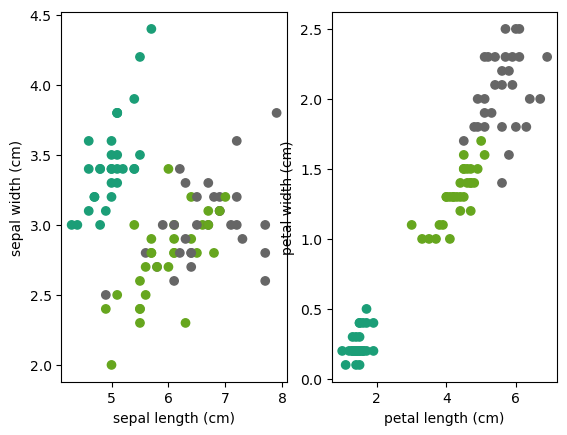

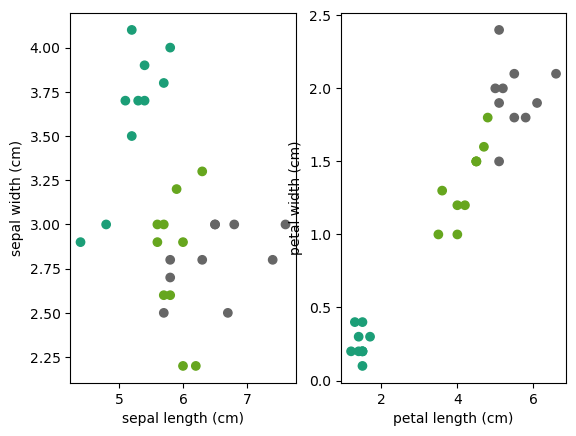

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

COLOR_MAP = cm.get_cmap('Dark2')

# Plot training Samples
plt.subplot(1, 2, 1)
plt.scatter(train_X[:,0],train_X[:,1],c=train_y, cmap=COLOR_MAP)
plt.xlabel(iris_data.feature_names[0])
plt.ylabel(iris_data.feature_names[1])

plt.subplot(1, 2, 2)
plt.scatter(train_X[:,2],train_X[:,3],c=train_y, cmap=COLOR_MAP)
plt.xlabel(iris_data.feature_names[2])
plt.ylabel(iris_data.feature_names[3])

plt.show()

# Plot test samples
plt.subplot(1, 2, 1)
plt.scatter(test_X[:,0],test_X[:,1],c=test_y, cmap=COLOR_MAP)
plt.xlabel(iris_data.feature_names[0])
plt.ylabel(iris_data.feature_names[1])

plt.subplot(1, 2, 2)
plt.scatter(test_X[:,2],test_X[:,3],c=test_y, cmap=COLOR_MAP)
plt.xlabel(iris_data.feature_names[2])
plt.ylabel(iris_data.feature_names[3])
plt.show()

### Multi-layer Perceptron Implementation

In [11]:
from sklearn.base import BaseEstimator, ClassifierMixin

class MultiLayerPerceptron(BaseEstimator, ClassifierMixin):

    ACTIVATION = {
         'sigmoid': (lambda x: 1/(1 + np.exp(-x))),
            'tanh': (lambda x: np.tanh(x)),
            'Relu': (lambda x: x*(x > 0)),
    }
    DERIVATIVE = {
         'sigmoid': (lambda x: x*(1-x)),
            'tanh': (lambda x: 1-x**2),
            'Relu': (lambda x: 1 * (x>0))
    }

    # Change 1 -> Use kargs instead of dict for redability
    def __init__(self, input_layer=4, hidden_layer=5, output_layer=3, learning_rate=0.005, max_epochs=600, activation_function='sigmoid'): 

        self.input_layer = input_layer
        self.hidden_layer = hidden_layer
        self.output_layer = output_layer
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.activation_function = self.ACTIVATION[activation_function.lower()]
        self.derivative_function = self.DERIVATIVE[activation_function.lower()]

        # Starting Bias and Weights
        self.WEIGHT_hidden = self.start_weights(self.input_layer, self.hidden_layer)
        self.WEIGHT_output = self.start_weights(self.hidden_layer, self.output_layer)
        self.BIAS_hidden = np.zeros((1, self.hidden_layer))    # Change 2 -> Start the bias as 0
        self.BIAS_output = np.zeros((1, self.output_layer))
        self.classes_number = 3

    def start_weights(self, x, y):
        return np.random.uniform(-1, 1, (x, y))   # Change 2 -> Use numpy array for weights

    def forward_propagation(self, x): # Change 3 -> Encapsulate foward propagation into a function to avoid repeated code
        self.OUTPUT_L1 = self.activation_function(np.dot(x, self.WEIGHT_hidden) + self.BIAS_hidden)
        self.OUTPUT_L2 = self.activation_function(np.dot(self.OUTPUT_L1, self.WEIGHT_output) + self.BIAS_output)

    def back_propagation(self, x): # Change 4 -> Use numpy functions for backpropagation algorithm

        # Calculate the error and delta for the output layer
        error_output = self.one_hot_gt - self.OUTPUT_L2
        delta_output = error_output * self.derivative_function(self.OUTPUT_L2)

        # Calculate the error and delta for the hidden layer
        error_hidden = np.dot(delta_output, self.WEIGHT_output.T)
        delta_hidden = error_hidden * self.derivative_function(self.OUTPUT_L1)

        # Update weights and biases
        self.WEIGHT_output += self.learning_rate * np.dot(self.OUTPUT_L1.T, delta_output)
        self.BIAS_output += self.learning_rate * np.sum(delta_output, axis=0, keepdims=True)

        self.WEIGHT_hidden += self.learning_rate * np.dot(x.T, delta_hidden)
        self.BIAS_hidden += self.learning_rate * np.sum(delta_hidden, axis=0, keepdims=True)

    def show_err_plot(self, v_error, v_epoch):
        plt.figure(figsize=(9,4))
        plt.plot(v_epoch, v_error, "m-",color="b", marker=11)
        plt.xlabel("Number of Epochs")
        plt.ylabel("Squared error (MSE)");
        plt.title("Error Minimization")
        plt.show()

    def predict(self, X):   # Change 5 -> Simplify prediction function
        self.forward_propagation(X)
        return np.argmax(self.OUTPUT_L2, axis=1)

    def fit(self, X, y):

        # One-hot encode labels
        self.one_hot_gt = np.zeros((len(X), self.classes_number))   # Change 7 -> Optimize one-hot encoding creation
        for idx in range(len(X)):
          self.one_hot_gt[idx, int(y[idx])] = 1 

        epoch_array = []
        error_array = []
        for count_epoch in range(self.max_epochs): # Change 8 -> Use a for loop for readability
            # Foward propagate
            self.forward_propagation(X)

            # Backpropagate - Update weights
            self.back_propagation(X)        # Change 9 -> Backpropagate only after running entire epoch

            # Calculate error
            if((count_epoch % 50 == 0) or (count_epoch == 1)):
                total_error = np.mean(0.5 * (self.one_hot_gt - self.OUTPUT_L2)**2)  # Change 10 -> Calculate error for entire epoch at once
                print("Epoch ", count_epoch, "- Total Error: ",total_error)
                error_array.append(total_error)
                epoch_array.append(count_epoch)

        self.show_err_plot(error_array, epoch_array)

def error_report(pred, ground_truth):
  hits = n_set = n_vers = n_virg = 0
  score_set = score_vers = score_virg = 0
  for j in range(len(ground_truth)):
      if(ground_truth[j] == 0): n_set += 1
      elif(ground_truth[j] == 1): n_vers += 1
      elif(ground_truth[j] == 2): n_virg += 1

  for i in range(len(ground_truth)):
      if ground_truth[i] == pred[i]:
          hits += 1
      if ground_truth[i] == pred[i] and ground_truth[i] == 0:
          score_set += 1
      elif ground_truth[i] == pred[i] and ground_truth[i] == 1:
          score_vers += 1
      elif ground_truth[i] == pred[i] and ground_truth[i] == 2:
          score_virg += 1

  hits = (hits / len(ground_truth)) * 100
  faults = 100 - hits
  acc_set = (score_set/n_set)*100
  acc_vers = (score_vers/n_vers)*100
  acc_virg = (score_virg/n_virg)*100

  print(f"""
  Porcents :{hits:.2f}% hits and {faults:.2f}% faults
  Total samples of test {len(ground_truth)}
    *Iris-Setosa: {n_set} samples {score_set} hits
        Accuracy: {acc_set:.2f}%
    *Iris-Versicolour: {n_vers} samples {score_vers} hits
        Accuracy: {acc_vers:.2f}%
    *Iris-Virginica: {n_virg} samples {score_virg} hits
        Accuracy: {acc_virg:.2f}%
  """)

  names = ["Setosa","Versicolour","Virginica"]
  x1 = [2.0,4.0,6.0]
  fig, ax = plt.subplots()
  r1 = plt.bar(x1[0], acc_set,color='orange',label='Iris-Setosa')
  r2 = plt.bar(x1[1], acc_vers,color='green',label='Iris-Versicolour')
  r3 = plt.bar(x1[2], acc_virg,color='purple',label='Iris-Virginica')
  plt.ylabel('Scores %')
  plt.xticks(x1, names);plt.title('Scores by iris flowers - Multilayer Perceptron')
  plt.show()

### Train model and validate parameters

Epoch  0 - Total Error:  0.14433141709354963
Epoch  1 - Total Error:  0.13358467001953506
Epoch  50 - Total Error:  0.10426220496065879
Epoch  100 - Total Error:  0.0831591821552969
Epoch  150 - Total Error:  0.06637047059579526
Epoch  200 - Total Error:  0.05781257105185458
Epoch  250 - Total Error:  0.05214052020297833
Epoch  300 - Total Error:  0.04743332496961735
Epoch  350 - Total Error:  0.04311618308714363
Epoch  400 - Total Error:  0.0390597019399953
Epoch  450 - Total Error:  0.03528372334704502
Epoch  500 - Total Error:  0.03184012351244508
Epoch  550 - Total Error:  0.028764895617703456


/tmp/ipykernel_4995/3031572517.py:60: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "m-" (-> color='m'). The keyword argument will take precedence.
  plt.plot(v_epoch, v_error, "m-",color="b", marker=11)


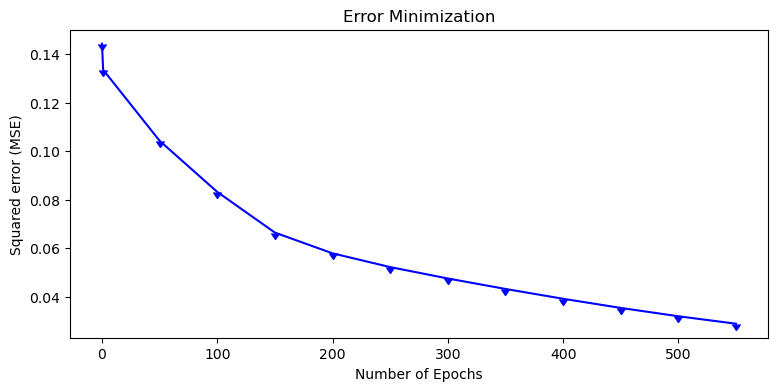


  Porcents :96.67% hits and 3.33% faults
  Total samples of test 30
    *Iris-Setosa: 10 samples 10 hits
        Accuracy: 100.00%
    *Iris-Versicolour: 10 samples 9 hits
        Accuracy: 90.00%
    *Iris-Virginica: 10 samples 10 hits
        Accuracy: 100.00%
  


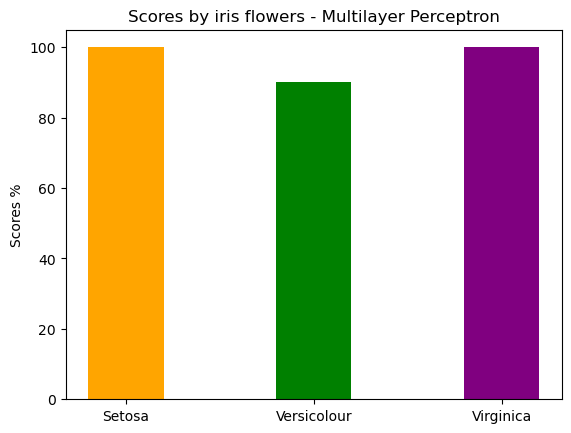

In [12]:
params_dict = {
    'input_layer': 4,
    'hidden_layer': 5,
    'output_layer': 3,
    'learning_rate': 0.005,
    'max_epochs': 600,
    'activation_function': 'sigmoid'
}
Perceptron = MultiLayerPerceptron(**params_dict)
Perceptron.fit(train_X,train_y)

# Test parameters
prev = Perceptron.predict(val_X)
error_report(prev, val_y)

### Evaluate model on test data


  Porcents :93.33% hits and 6.67% faults
  Total samples of test 30
    *Iris-Setosa: 10 samples 10 hits
        Accuracy: 100.00%
    *Iris-Versicolour: 10 samples 8 hits
        Accuracy: 80.00%
    *Iris-Virginica: 10 samples 10 hits
        Accuracy: 100.00%
  


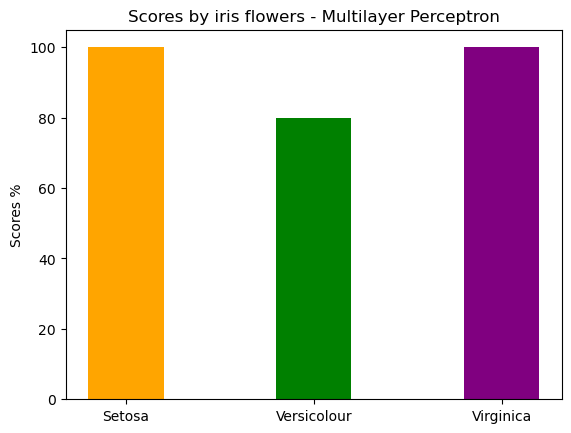

In [13]:
prev = Perceptron.predict(test_X)
error_report(prev, test_y)